<a href="https://colab.research.google.com/github/anabel212018/Telecom_Churn_Analisis_parte2/blob/main/Telecom_X_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cargar librerías


In [23]:
import pandas as pd
import numpy as np

##Conectar Google Drive y carga de dataset

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
df = pd.read_csv("/content/drive/MyDrive/TelecomX/telecom_clean.csv")

In [26]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   int64  
 5   customer.Dependents        7032 non-null   int64  
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   int64  
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   objec

#Revisamos valores

In [27]:
df["Churn"].unique()

array([0., 1.])

In [28]:
df["Churn"].isna().sum()

np.int64(0)

###Eliminar la columna identificadora

In [29]:
df = df.drop(columns=["customerID"])

In [30]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

###Separamos variables predictoras y objetivo

In [31]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

###Convertir variables categóricas a numéricas utilizando One-Hot Encoding

In [32]:
X = pd.get_dummies(X, drop_first=True)

In [33]:
X.head()

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,...,internet.TechSupport_Yes,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.186667,False,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,1.996667,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,2.463333,True,...,False,False,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,3.266667,True,...,False,False,True,False,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,2.796667,False,...,True,False,True,False,False,False,False,False,False,True


###Revisar el balance de clases

In [34]:
y.value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [35]:
y.value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


El análisis del balance de clases muestra que aproximadamente 73 % de los clientes permanecen en el servicio, mientras que 27 % cancelan.
Aunque existe un desbalance moderado, la proporción es común en problemas de churn y permite entrenar modelos de clasificación sin necesidad de aplicar técnicas de balanceo adicionales.

##Dividir datos en entrenamiento y prueba

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
X_train.shape
X_test.shape

(1407, 31)

Dado este resultado: 1407 registros para prueba y 31 variables predictoras después del One-Hot Encoding. Se pasa a la fase de entrenamiento de modelos predictivos

##Normalizar datos

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Entrenamiento del primer modelo de regresión logística

In [39]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

##Hacer predicciones

In [40]:
y_pred_log = log_model.predict(X_test_scaled)

##Evaluar el modelo

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8009950248756219
[[929 104]
 [176 198]]
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1033
         1.0       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



##Entrenamiento del segundo modelo de regresión: Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

###Predicciones de Random Forest

In [43]:
y_pred_rf = rf_model.predict(X_test)

###Evaluar Random Forest

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7953091684434968
[[932 101]
 [187 187]]
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.87      1033
         1.0       0.65      0.50      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



xxxx

In [61]:
y_pred = rf_model.predict(X_test)

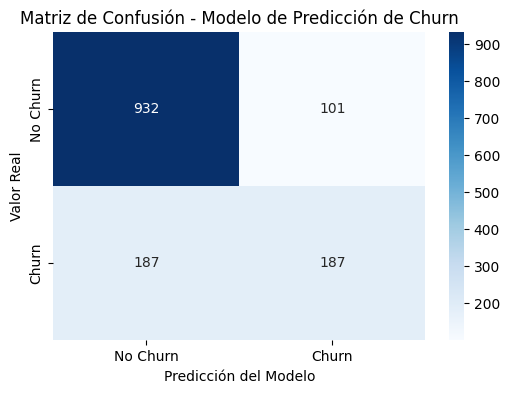

In [63]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión - Modelo de Predicción de Churn")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")

plt.show()

###Importancia de variables

In [45]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
account.Charges.Total,0.167377
customer.tenure,0.155919
account.Charges.Monthly,0.132326
Cuentas_Diarias,0.127387
account.PaymentMethod_Electronic check,0.040817
internet.InternetService_Fiber optic,0.033801
account.Contract_Two year,0.030066
customer.gender_Male,0.024481
account.PaperlessBilling,0.023792
customer.Partner,0.021803


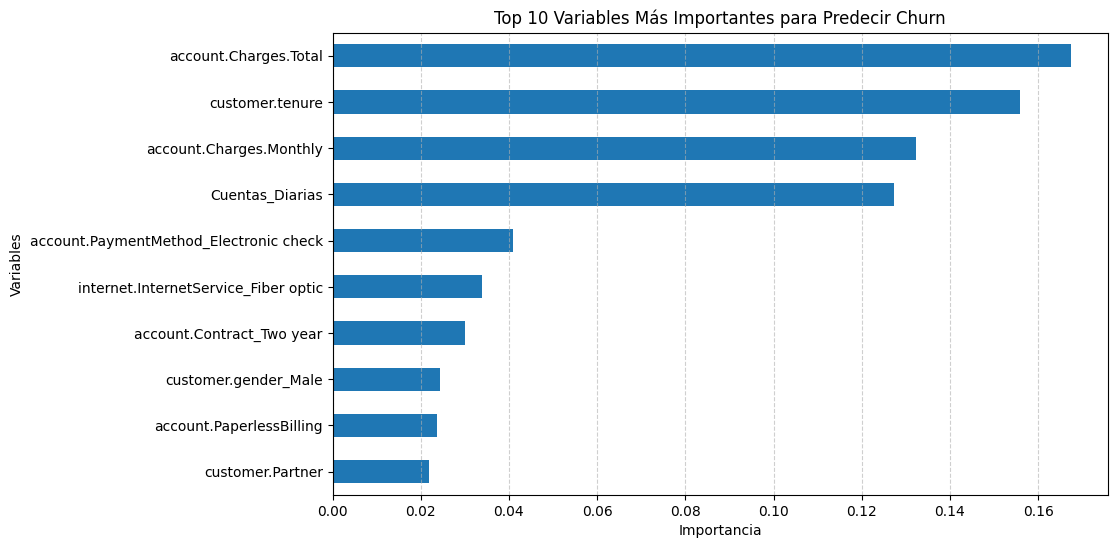

In [49]:
import matplotlib.pyplot as plt

# ordenar variables
feature_importance_sorted = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

feature_importance_sorted.sort_values().plot(kind="barh")

plt.title("Top 10 Variables Más Importantes para Predecir Churn")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

###Distribución de Churn

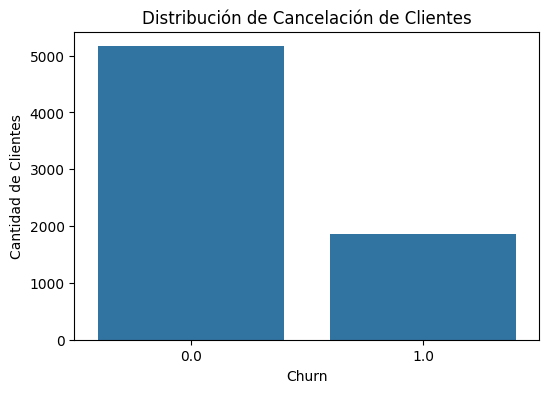

In [52]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Distribución de Cancelación de Clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de Clientes")

plt.show()

Se observa que la mayoría de clientes no cancelan el servicio, sin embargo existe un porcentaje significativo de churn que justifica el uso de modelos predictivos.

###Churn versus Tipo de contrato

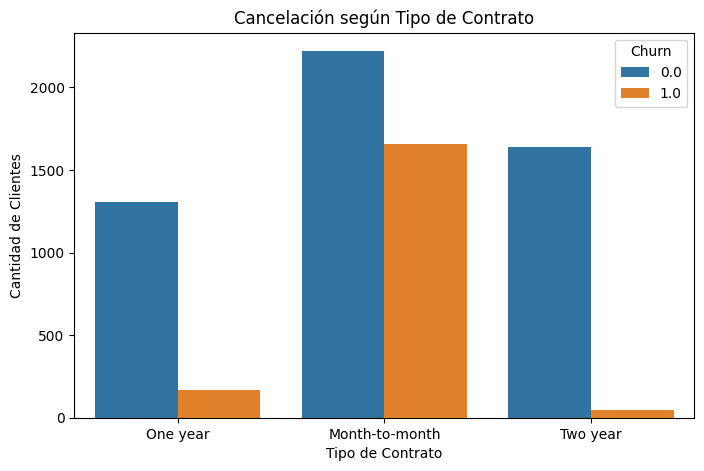

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(x="account.Contract", hue="Churn", data=df)

plt.title("Cancelación según Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Cantidad de Clientes")

plt.show()

Los clientes con contratos mensuales presentan mayores tasas de cancelación que aquellos con contratos de largo plazo.

###Churn versus cargos mensuales

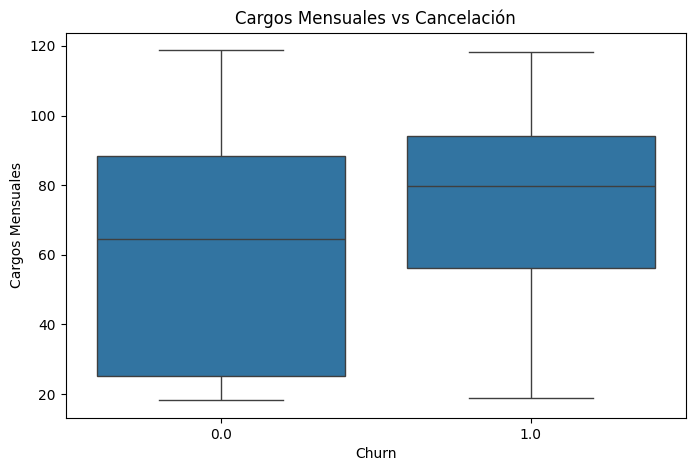

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)

plt.title("Cargos Mensuales vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Cargos Mensuales")

plt.show()

Los clientes que cancelan el servicio tienden a tener cargos mensuales más altos.

###Antiguedad del cliente versus Churn

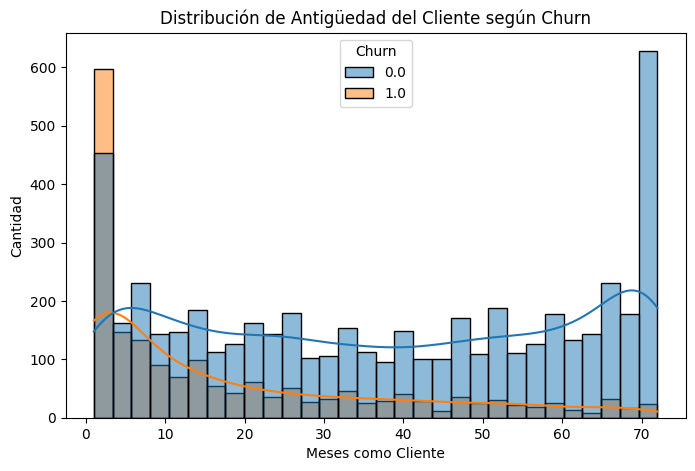

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="customer.tenure", hue="Churn", bins=30, kde=True)

plt.title("Distribución de Antigüedad del Cliente según Churn")
plt.xlabel("Meses como Cliente")
plt.ylabel("Cantidad")

plt.show()

Los clientes con menor antigüedad presentan mayor probabilidad de cancelar el servicio.

Generar probabilidades del modelo

In [65]:
y_prob = rf_model.predict_proba(X_test)[:,1]
y_prob

array([0.03, 0.24, 0.  , ..., 0.26, 0.01, 0.57])

Agregamos la curva ROC

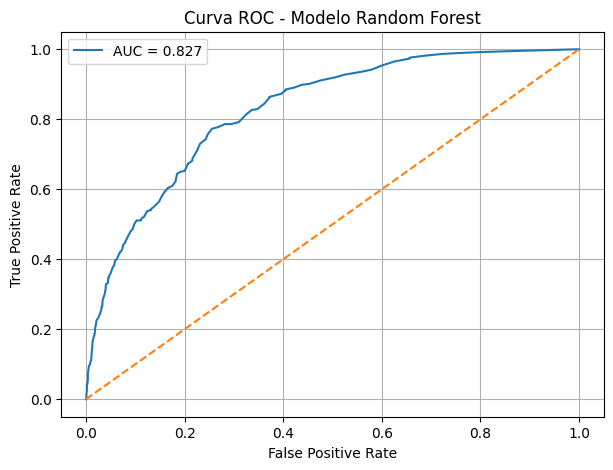

In [66]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Random Forest")

plt.legend()
plt.grid()

plt.show()

Evaluación mediante Curva ROC

La curva ROC permite evaluar la capacidad del modelo para distinguir entre clientes que cancelan el servicio y aquellos que permanecen activos.

El valor de AUC (Area Under the Curve) obtenido indica el nivel de discriminación del modelo. Cuanto más cercano a 1 sea el valor, mejor es la capacidad predictiva.

Este análisis complementa métricas como accuracy, precision y recall, proporcionando una visión más completa del desempeño del modelo.




In [67]:
probabilidades = rf_model.predict_proba(X_test)

df_prob = X_test.copy()
df_prob["Probabilidad_Churn"] = probabilidades[:,1]

df_prob.head()

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,customer.gender_Male,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check,Probabilidad_Churn
984,0,0,0,12,1,0,19.7,260.90,0.656667,False,...,True,False,True,False,True,False,False,False,True,0.03
654,0,0,0,7,1,1,69.9,497.30,2.330000,False,...,False,False,False,False,False,False,False,False,True,0.24
4341,0,0,0,62,1,0,23.4,1429.65,0.780000,True,...,True,False,True,False,False,True,False,False,False,0.00
3526,0,0,0,10,0,0,29.5,255.25,0.983333,True,...,False,False,False,False,False,False,False,False,True,0.23
4590,0,1,1,8,1,1,51.3,411.60,1.710000,True,...,False,False,False,False,False,False,True,False,False,0.18


In [50]:
print("Proyecto finalizado: Modelo de predicción de churn para Telecom X.")
print("Modelo más efectivo: Random Forest")
print("Principales variables predictivas identificadas.")

Proyecto finalizado: Modelo de predicción de churn para Telecom X.
Modelo más efectivo: Random Forest
Principales variables predictivas identificadas.


In [46]:
print("Proyecto finalizado: Pipeline de predicción de churn completado.")

Proyecto finalizado: Pipeline de predicción de churn completado.


1️⃣ El Problema

Las empresas de telecomunicaciones enfrentan uno de los desafíos más costosos del sector: la cancelación de clientes (churn).

Cada cliente que abandona el servicio representa:

pérdida de ingresos recurrentes

aumento de costos de adquisición

deterioro del crecimiento del negocio

Por esta razón, anticipar qué clientes tienen mayor probabilidad de cancelar se vuelve un objetivo estratégico.

Este proyecto busca responder una pregunta clave:

¿Podemos identificar con anticipación qué clientes tienen mayor probabilidad de cancelar el servicio?

2️⃣ Exploración de los datos

Se realizó un proceso de limpieza y exploración del dataset de clientes de Telecom X.

El análisis inicial permitió observar:

distribución de clientes activos vs cancelados

características demográficas

tipo de contratos

tipo de servicio de internet

estructura de cargos mensuales

Este proceso permitió entender cómo se comportan los clientes dentro del servicio.

3️⃣ Hallazgos iniciales

Durante el análisis exploratorio se identificaron algunos patrones importantes:

Clientes con contratos mensuales presentan mayor churn.

Los contratos de corto plazo muestran mayor volatilidad en comparación con contratos anuales o bianuales.

Los cargos mensuales elevados se asocian con mayor cancelación.

Esto sugiere que algunos clientes perciben que el costo del servicio no compensa el valor recibido.

Los clientes con menor antigüedad presentan mayor riesgo de churn.

Los primeros meses del cliente representan un período crítico para la fidelización.

4️⃣ Desarrollo del modelo predictivo

Para predecir la cancelación de clientes se entrenaron dos modelos de Machine Learning:

Regresión Logística

Random Forest

Ambos modelos fueron evaluados utilizando:

Accuracy

Precision

Recall

F1 Score

Curva ROC

El modelo Random Forest mostró mejor capacidad para identificar clientes con riesgo de churn, debido a su capacidad para capturar relaciones complejas entre variables.

5️⃣ Variables más importantes

El modelo identificó que los factores más influyentes en la cancelación son:

cargos totales del cliente

antigüedad del cliente (tenure)

cargos mensuales

tipo de contrato

método de pago

tipo de servicio de internet

Esto indica que el churn está principalmente relacionado con factores económicos y contractuales.

6️⃣ Insights del análisis

A partir del modelo y del análisis de variables se identificaron cuatro insights clave:

1️⃣ La etapa más crítica del cliente son los primeros meses.

Clientes nuevos presentan mayor probabilidad de cancelar.

2️⃣ El precio del servicio influye significativamente en la decisión de churn.

Clientes con cargos mensuales más altos tienen mayor tendencia a cancelar.

3️⃣ Los contratos de largo plazo reducen el churn.

Los clientes con contratos de dos años presentan mayor estabilidad.

4️⃣ Algunos segmentos premium muestran mayor sensibilidad a la experiencia del servicio.

Clientes con fibra óptica tienen expectativas más altas sobre la calidad del servicio.

7️⃣ Recomendaciones estratégicas

Con base en los resultados del análisis se sugieren las siguientes estrategias:

Programas de fidelización para clientes nuevos

Los primeros meses del cliente deberían incluir seguimiento y acompañamiento.

Incentivos para contratos de largo plazo

Ofrecer descuentos o beneficios para contratos anuales o bianuales.

Optimización de la relación precio–valor

Revisar estructura de cargos mensuales para segmentos sensibles al precio.

Monitoreo de clientes de alto valor

Clientes con servicios premium requieren mayor calidad de experiencia.

8️⃣ Impacto potencial del modelo

La implementación de modelos predictivos de churn permite a las empresas:

identificar clientes con alto riesgo de cancelación

intervenir antes de que el cliente abandone

optimizar estrategias de retención

reducir pérdida de ingresos recurrentes

Esto transforma la gestión de clientes desde un enfoque reactivo hacia uno predictivo y basado en datos.